In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os, scipy
import matplotlib.colors as mcolors
import pickle


# We import the model, stimuli, and the optimal control package
from neurolib.models.wc import WCModel
from neurolib.utils.stimulus import ZeroInput
from neurolib.optimal_control import oc_wc
from neurolib.optimal_control.oc_utils.plot_oc import plot_oc_nw
from neurolib.optimal_control import cost_functions

# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2

options = {
    'node_color': 'lightgray',
    'node_size': 1000,
    'width': 2,
    'arrowstyle': '-|>',
    'arrowsize': 20,
    'font_size' : 20,
    'font_weight' : 'bold',
    }

0.0 --------------------------------------


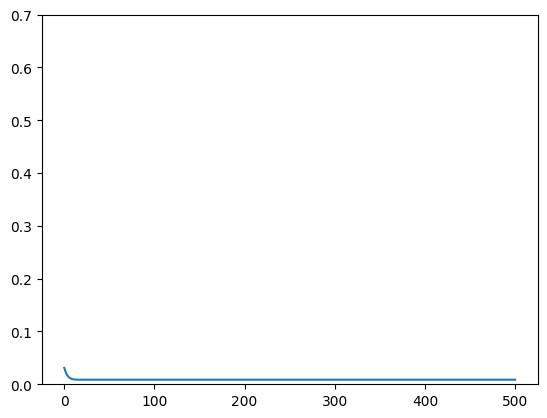

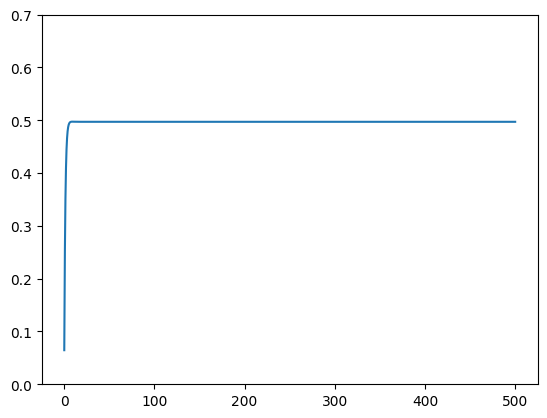

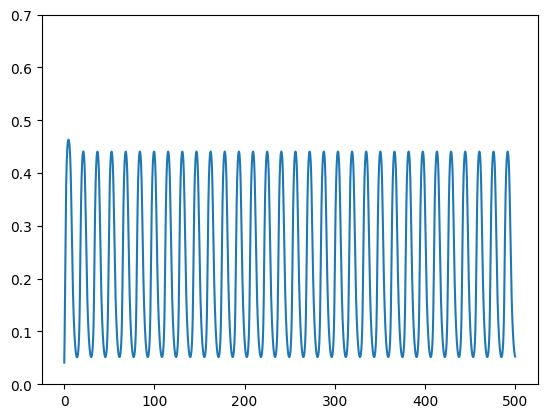

period =  15.683333333333334
0.1 --------------------------------------


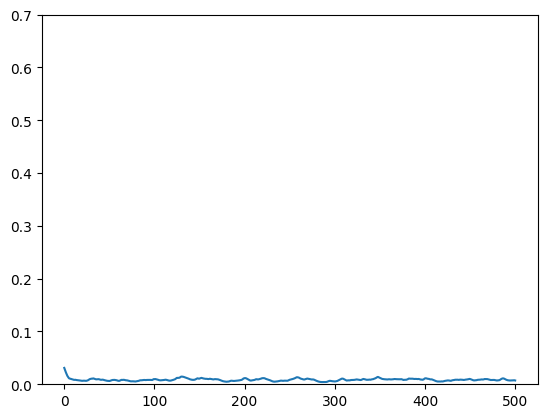

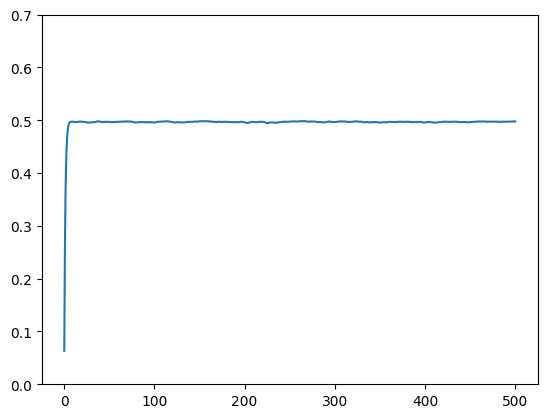

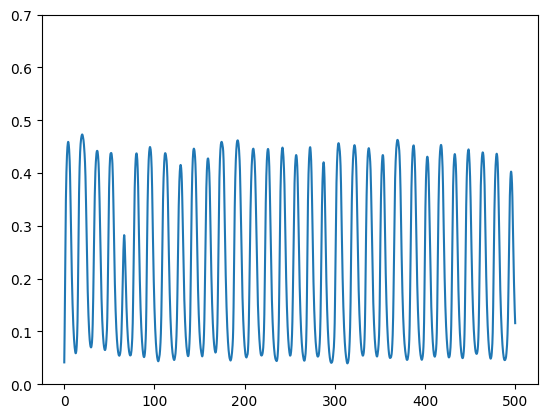

0.2 --------------------------------------


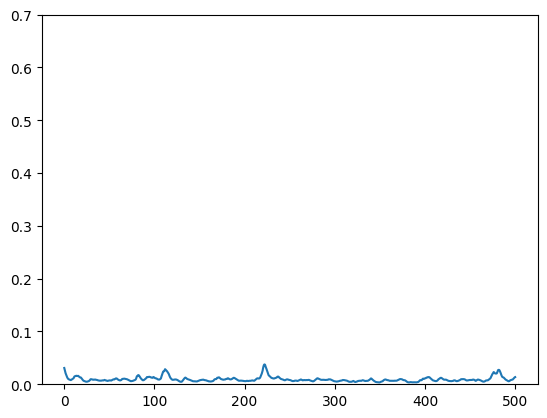

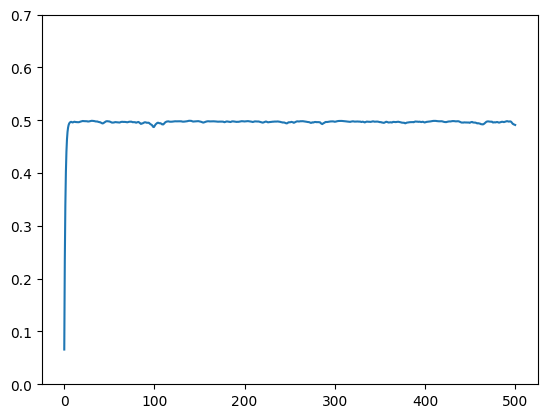

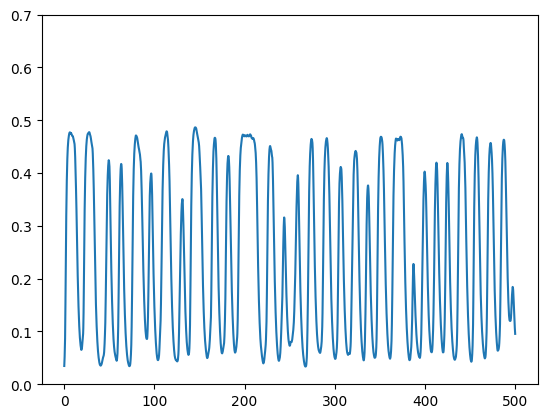

0.3 --------------------------------------


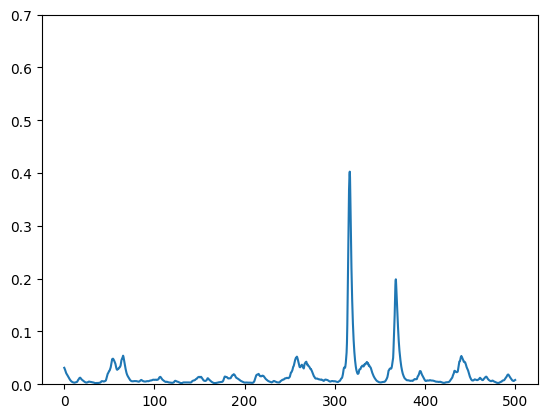

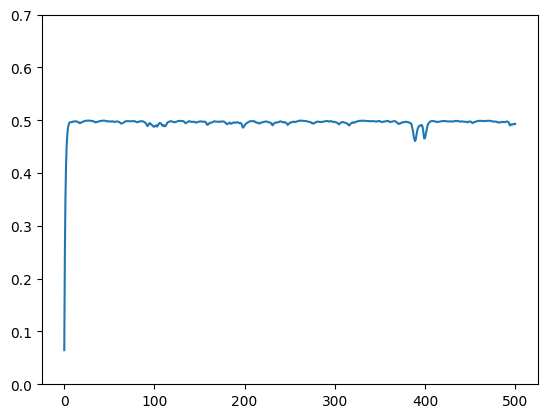

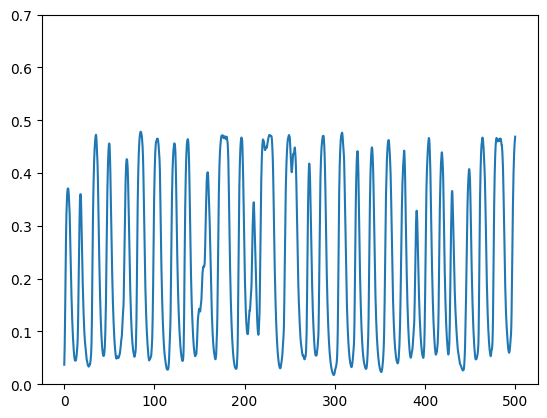

0.4 --------------------------------------


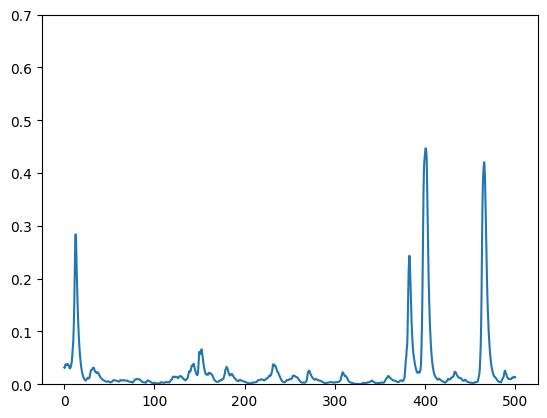

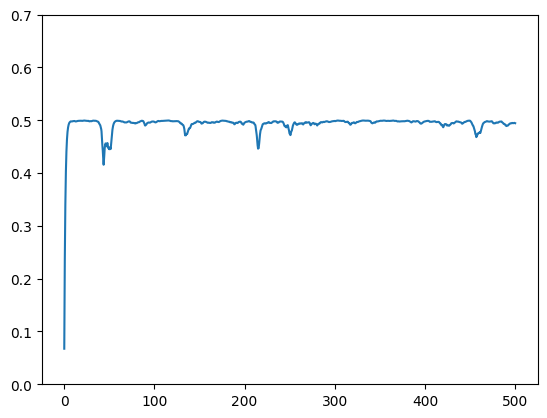

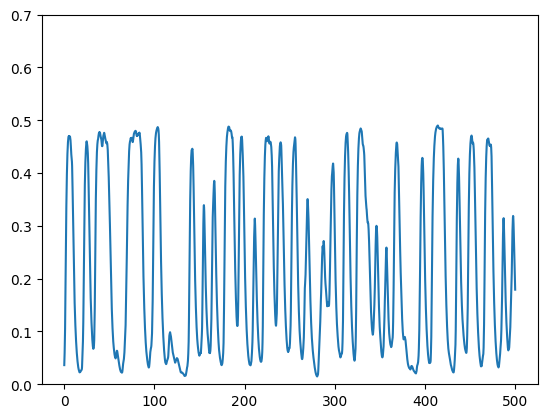

0.5 --------------------------------------


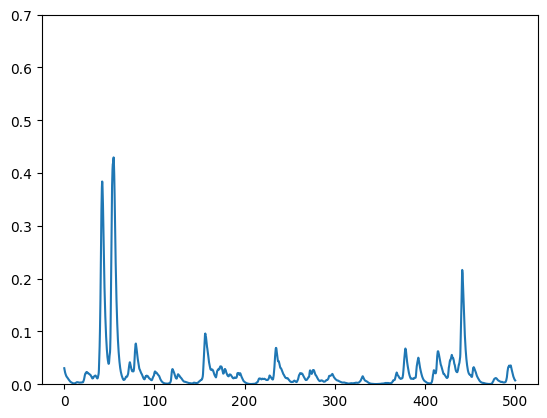

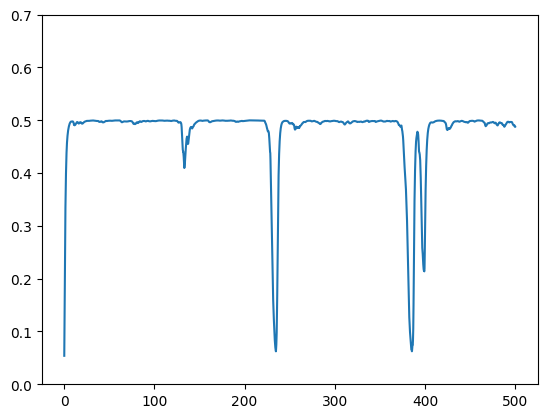

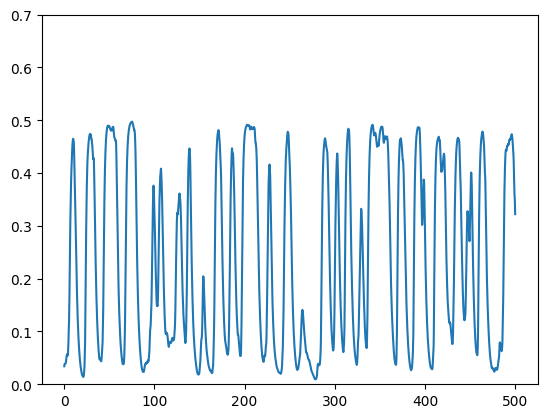

In [3]:
comp_points = [[0., 0.5], [4., 0.5], [2., 0.5]]

N = 1
dir = "images_1n"

colors = []
n = 0
for col in mcolors.TABLEAU_COLORS:
    colors.append(col)
    n += 1
    if n >= N: break

model = WCModel()

dt = 0.1
model.params['dt'] = dt # Integration time step, ms
model.params['duration'] = 1. * 500 # Simulation time, ms
model.params.signalV = 1.

zero_input = ZeroInput().generate_input(duration=model.params['duration']+model.params.dt, dt=model.params.dt)
rect_input = np.vstack( (zero_input)*2 )
#rect_input[0,:500] = 1.
#rect_input[0,2000:2500] = -1.

for sigg in [0., 0.1, 0.2, 0.3, 0.4, 0.5]:
    print(sigg, "--------------------------------------")
    model.params.sigma_ou = sigg

    for p in comp_points:
        model.params["exc_ext"] = p[0] + rect_input[0,:]
        model.params["inh_ext"] = p[1]
        model.run()

        plt.plot(model.t, model.exc[0,:], color=colors[0])
        plt.ylim(0, 0.7)
        plt.show()

    
    if sigg == 0.:
        peaks = scipy.signal.find_peaks(model.exc[0,2000:5000])[0]
        plist = []
        for pind in range(1, len(peaks)):
            plist.append(model.params.dt * (peaks[pind]-peaks[pind-1]))

        period = np.mean(plist)
        print("period = ", period)

In [4]:
def getperiods(x, target_period, duration):
    timing_list = [None] * N
    periods_list = [None] * N

    npeaks = np.floor(duration / target_period)

    for n in range(N):
        prom = 10.

        while True:
            timing_list[n] = scipy.signal.find_peaks(x[n, 0, 300:], prominence=prom)[0]
            if prom < 1e-6:
                break
            if len(timing_list[n]) < npeaks:
                prom *= 0.8
            else: break    
        
        periods_list[n] = []
        if len(timing_list[n]) < 3:
            continue
        for pind in range(1, len(timing_list[n])):
            periods_list[n].append(model.params.dt * (timing_list[n][pind]-timing_list[n][pind-1]))

    return timing_list, periods_list

In [5]:
controlmat = np.zeros((N,2))
controlmat[:,0] = 1.

costmat = np.zeros((N, 2))
costmat[:,0] = 1.

duration = 200.
model.params.duration = duration
zero_input0 = ZeroInput().generate_input(duration=duration+model.params.dt, dt=model.params.dt)
zero_input = np.vstack( ([zero_input0]*2) )[np.newaxis,:,:]
zero_control = np.vstack( ([zero_input]*N))

print(zero_input0.shape, zero_input.shape, zero_control.shape)

w2_array = [1e-4, 5. * 1e-4, 1e-3, 5. * 1e-3]
target_array = [0.7*period, period, 1.3*period]
M = 10
sigma_array = [0., 0.1, 0.2, 0.3, 0.4, 0.5]

results = dict()
results["controls"] = [ [ [ [None, None, None, None, None, None], [None, None, None, None, None, None], [None, None, None, None, None, None], [None, None, None, None, None, None], [None, None, None, None, None, None]], ], 
                        [ [ [None, None, None, None, None, None], [None, None, None, None, None, None], [None, None, None, None, None, None], [None, None, None, None, None, None], [None, None, None, None, None, None]], ], 
                        [ [ [None, None, None, None, None, None], [None, None, None, None, None, None], [None, None, None, None, None, None], [None, None, None, None, None, None], [None, None, None, None, None, None]], ], 
]
results["periods"] = [ [ [ [None, None, None, None, None, None], [None, None, None, None, None, None], [None, None, None, None, None, None], [None, None, None, None, None, None], [None, None, None, None, None, None]], ], 
                        [ [ [None, None, None, None, None, None], [None, None, None, None, None, None], [None, None, None, None, None, None], [None, None, None, None, None, None], [None, None, None, None, None, None]], ], 
                        [ [ [None, None, None, None, None, None], [None, None, None, None, None, None], [None, None, None, None, None, None], [None, None, None, None, None, None], [None, None, None, None, None, None]], ], 
]
results["timings"] = [ [ [ [None, None, None, None, None, None], [None, None, None, None, None, None], [None, None, None, None, None, None], [None, None, None, None, None, None], [None, None, None, None, None, None]], ], 
                        [ [ [None, None, None, None, None, None], [None, None, None, None, None, None], [None, None, None, None, None, None], [None, None, None, None, None, None], [None, None, None, None, None, None]], ], 
                        [ [ [None, None, None, None, None, None], [None, None, None, None, None, None], [None, None, None, None, None, None], [None, None, None, None, None, None], [None, None, None, None, None, None]], ], 
]
results["costs"] = np.zeros((len(comp_points), len(target_array), len(w2_array), len(sigma_array)))
results["conv"] = np.zeros((len(comp_points), len(target_array), len(w2_array), len(sigma_array)))
results["Fcost"] = np.zeros((len(comp_points), len(target_array), len(w2_array), len(sigma_array)))

(1, 2001) (1, 2, 2001) (1, 2, 2001)


pind =  0
itar =  0
w2 =  0.0001
sigma =  0.0
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -0.18185915108243855
Converged in iteration 2 with cost -0.18185915108243855
Final cost : -0.18185915108243855
Compute control for a deterministic system
Cost in iteration 0: -0.18185915108243855
Converged in iteration 1 with cost -0.18185915108243855
Final cost : -0.18185915108243855
Compute control for a deterministic system
Cost in iteration 0: -0.18185915108243855
Converged in iteration 1 with cost -0.18185915108243855
Final cost : -0.18185915108243855
MININD =  0


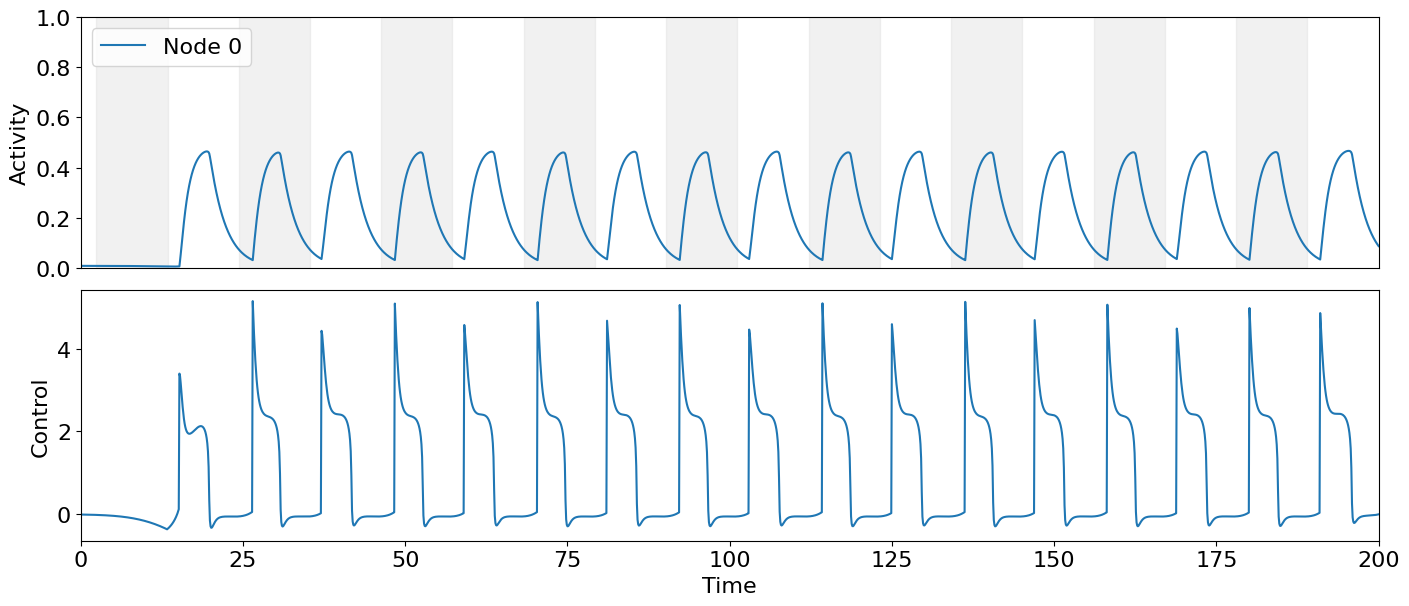

sigma =  0.1
Optimal control with target oscillation period
Compute control for a noisy system
Mean cost in iteration 0: -0.18125395650855708
Mean cost in iteration 5: -0.18091829741123916
Mean cost in iteration 10: -0.1810351005298029
Mean cost in iteration 15: -0.18122626112052775
Mean cost in iteration 20: -0.18088270948932963
Mean cost in iteration 25: -0.18129989470711344
Mean cost in iteration 30: -0.18150911901070774
Minimal cost found at iteration 9
Final cost validated with 100 noise realizations : -0.18086110400921698
Compute control for a noisy system
Mean cost in iteration 0: -0.18097495042606623
Mean cost in iteration 5: -0.181480407949899
Mean cost in iteration 10: -0.18123573739068224
Mean cost in iteration 15: -0.18118868019660522
Mean cost in iteration 20: -0.1813225790404652
Mean cost in iteration 25: -0.1804427263632667
Mean cost in iteration 30: -0.18080269404805374
Minimal cost found at iteration 48
Final cost validated with 100 noise realizations : -0.181256920203

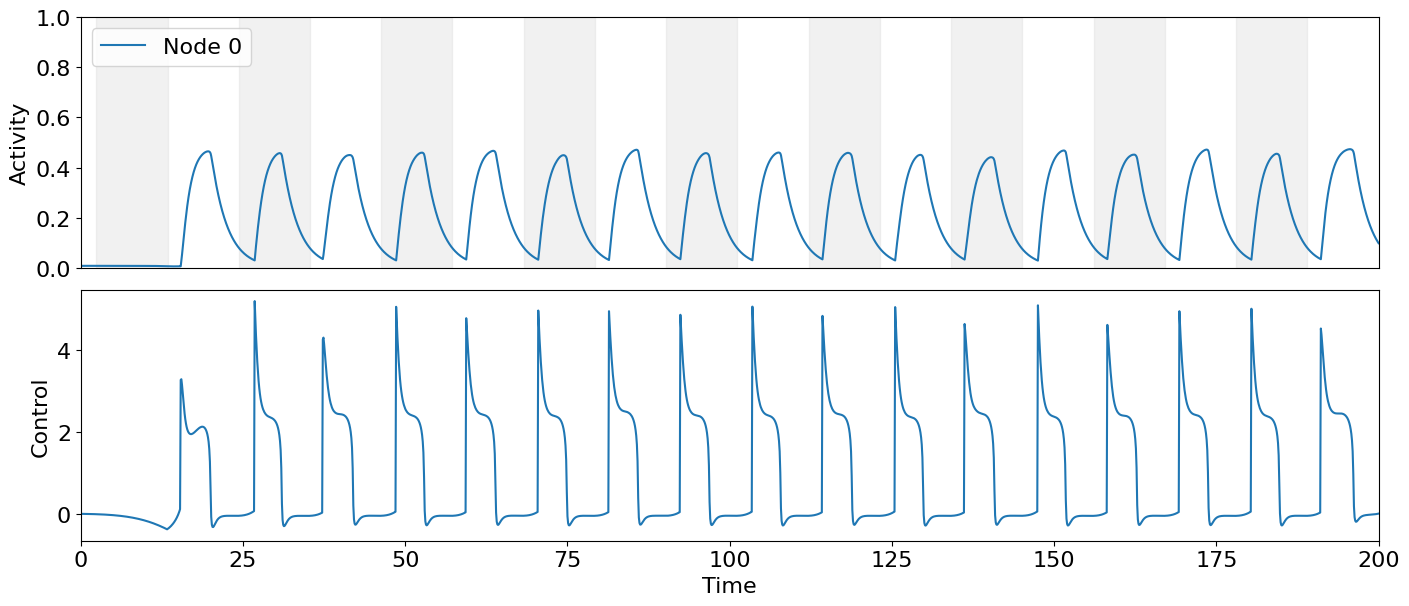

sigma =  0.2
Optimal control with target oscillation period
Compute control for a noisy system
Mean cost in iteration 0: -0.17378228060774287
Mean cost in iteration 5: -0.17531643778699418
Mean cost in iteration 10: -0.177948086379265
Mean cost in iteration 15: -0.17477351957156356
Mean cost in iteration 20: -0.17751276654269615
Mean cost in iteration 25: -0.17651967856397327
Mean cost in iteration 30: -0.17507691536366016
Minimal cost found at iteration 22
Final cost validated with 100 noise realizations : -0.17635823920995414
Compute control for a noisy system
Mean cost in iteration 0: -0.17671913213460358
Mean cost in iteration 5: -0.17524810985077885
Mean cost in iteration 10: -0.17722657377721115
Mean cost in iteration 15: -0.17562161600624415
Mean cost in iteration 20: -0.1745811818193605
Mean cost in iteration 25: -0.17741283819173437
Mean cost in iteration 30: -0.17423645234469182
Minimal cost found at iteration 22
Final cost validated with 100 noise realizations : -0.176562965

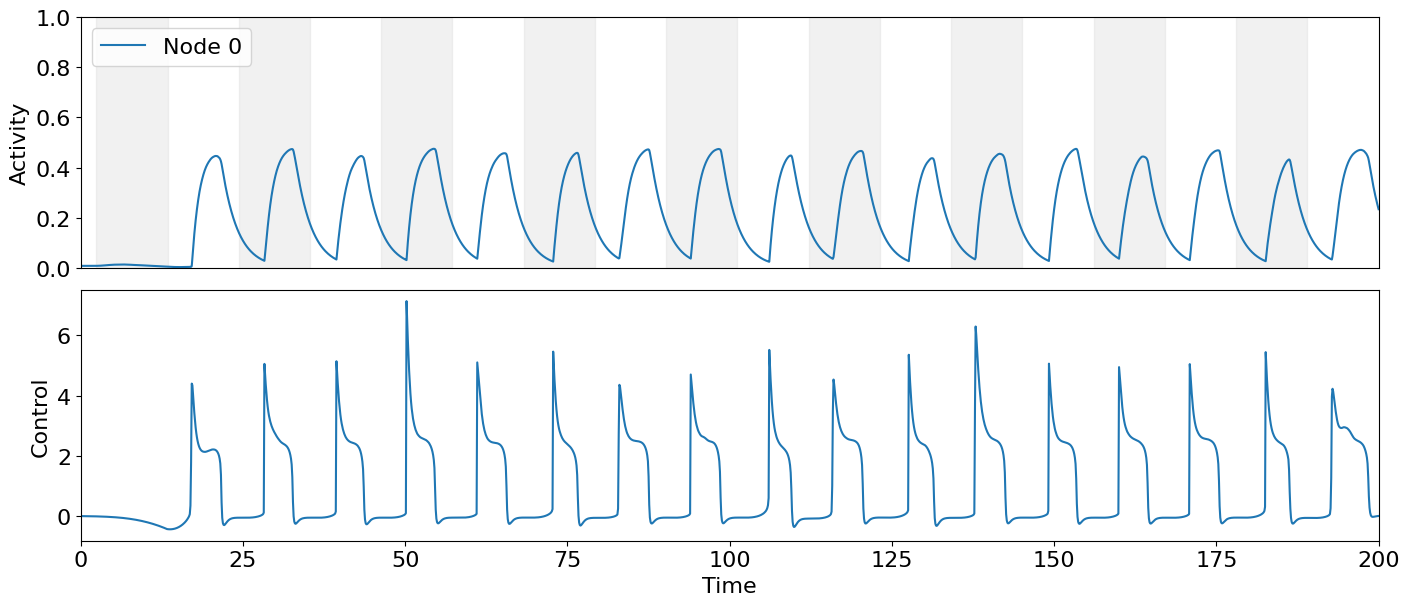

sigma =  0.3
Optimal control with target oscillation period
Compute control for a noisy system
Mean cost in iteration 0: -0.16540217104507277
Mean cost in iteration 5: -0.16339937519861086
Mean cost in iteration 10: -0.16075808208456893
Mean cost in iteration 15: -0.15894191807293742
Mean cost in iteration 20: -0.16106150593023374
Mean cost in iteration 25: -0.1643215415323374
Mean cost in iteration 30: -0.16224430332625708
Minimal cost found at iteration 0
Final cost validated with 100 noise realizations : -0.16267673649397957
Compute control for a noisy system
Mean cost in iteration 0: -0.16006564800091633
Mean cost in iteration 5: -0.15748060510165535
Mean cost in iteration 10: -0.15561200782673978
Mean cost in iteration 15: -0.1592511599100564
Mean cost in iteration 20: -0.15924526994011062
Mean cost in iteration 25: -0.16077610269041764
Mean cost in iteration 30: -0.1582077843715901
Minimal cost found at iteration 0
Final cost validated with 100 noise realizations : -0.16278693792

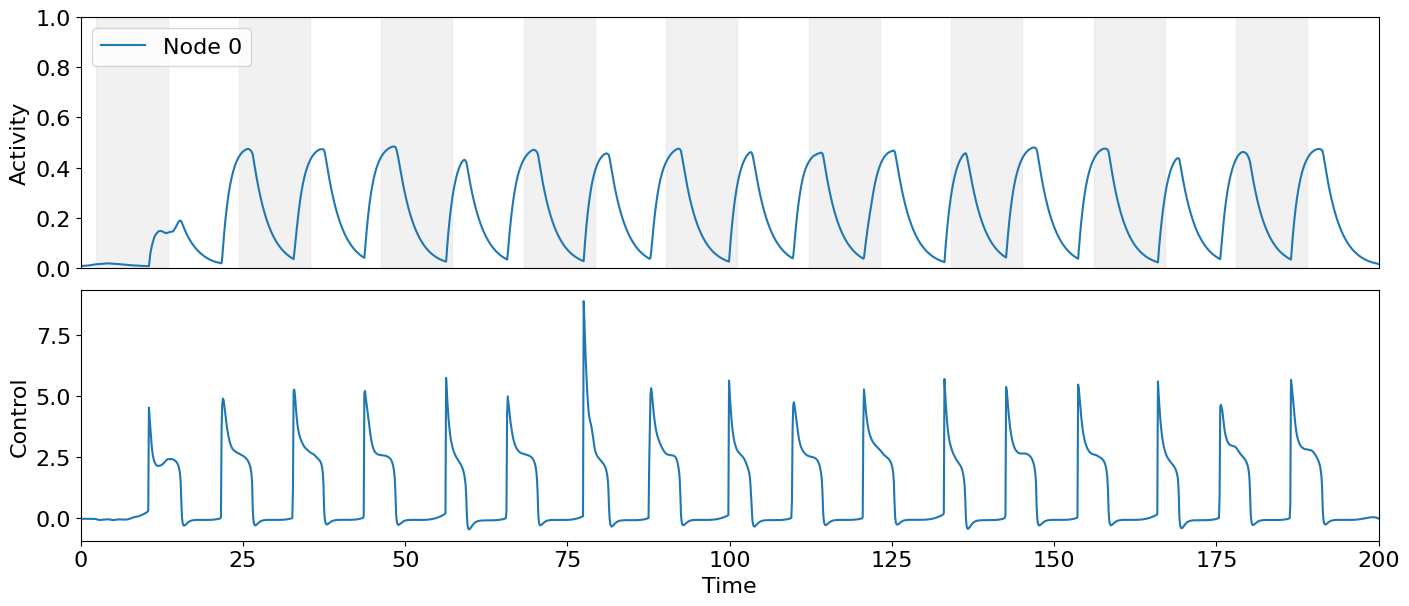

sigma =  0.4
Optimal control with target oscillation period
Compute control for a noisy system
Mean cost in iteration 0: -0.15772532286974678
Mean cost in iteration 5: -0.1543465478250126
Mean cost in iteration 10: -0.1551168350230984
Mean cost in iteration 15: -0.14949096692800953
Mean cost in iteration 20: -0.14676950569437536
Mean cost in iteration 25: -0.15903706180252883
Mean cost in iteration 30: -0.15799091348392205
Minimal cost found at iteration 27
Final cost validated with 100 noise realizations : -0.15895277704697516
Compute control for a noisy system
Mean cost in iteration 0: -0.15977175279618835
Mean cost in iteration 5: -0.15598240904594818
Mean cost in iteration 10: -0.1606830235796917
Mean cost in iteration 15: -0.15848405386532619
Mean cost in iteration 20: -0.15461534834561355
Mean cost in iteration 25: -0.1540453251767126
Mean cost in iteration 30: -0.15551580908823925
Minimal cost found at iteration 40
Final cost validated with 100 noise realizations : -0.1578561747

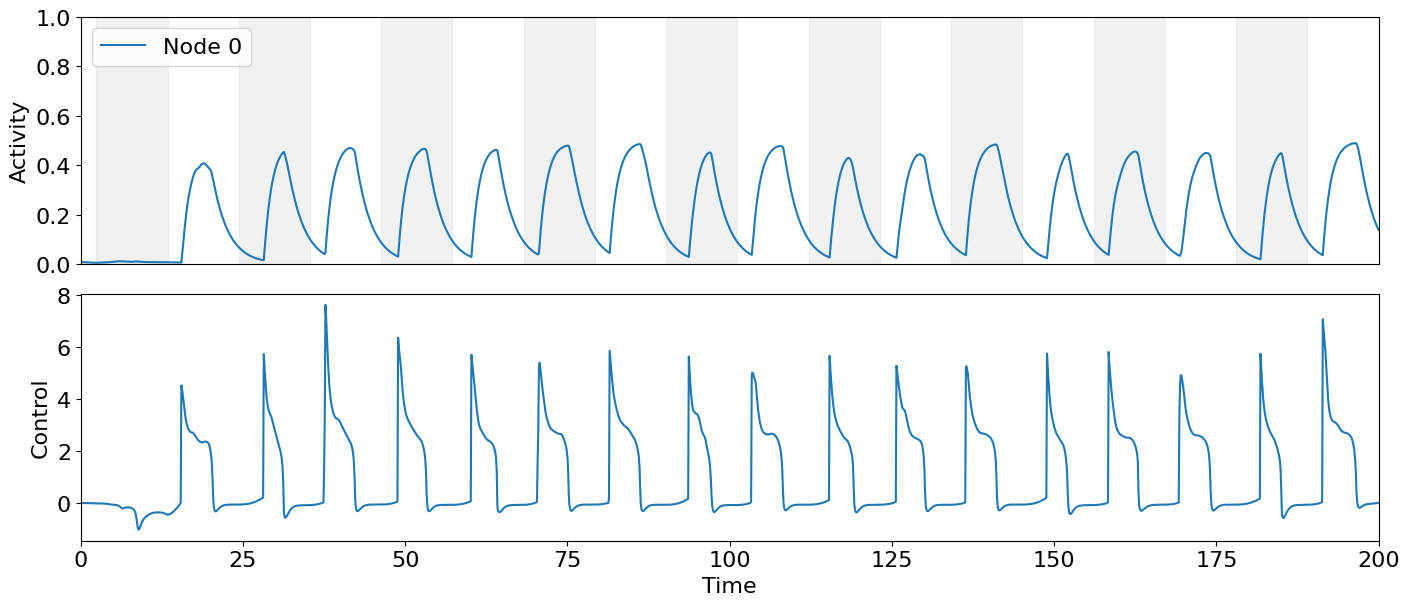

sigma =  0.5
Optimal control with target oscillation period
Compute control for a noisy system
Mean cost in iteration 0: -0.14561691359591672
Mean cost in iteration 5: -0.14199698679653924
Mean cost in iteration 10: -0.14970958658962452
Mean cost in iteration 15: -0.14684960340732495
Mean cost in iteration 20: -0.1445139132940017
Mean cost in iteration 25: -0.14245045647292062
Mean cost in iteration 30: -0.14583510097586283
Minimal cost found at iteration 22
Final cost validated with 100 noise realizations : -0.15075989596196385
Compute control for a noisy system
Mean cost in iteration 0: -0.1516152607011427
Mean cost in iteration 5: -0.1448484232091397
Mean cost in iteration 10: -0.14028256377351228
Mean cost in iteration 15: -0.1403195149219773
Mean cost in iteration 20: -0.14605422749256425
Mean cost in iteration 25: -0.14556614074737012
Mean cost in iteration 30: -0.14015213678245358
Minimal cost found at iteration 22
Final cost validated with 100 noise realizations : -0.1488131956

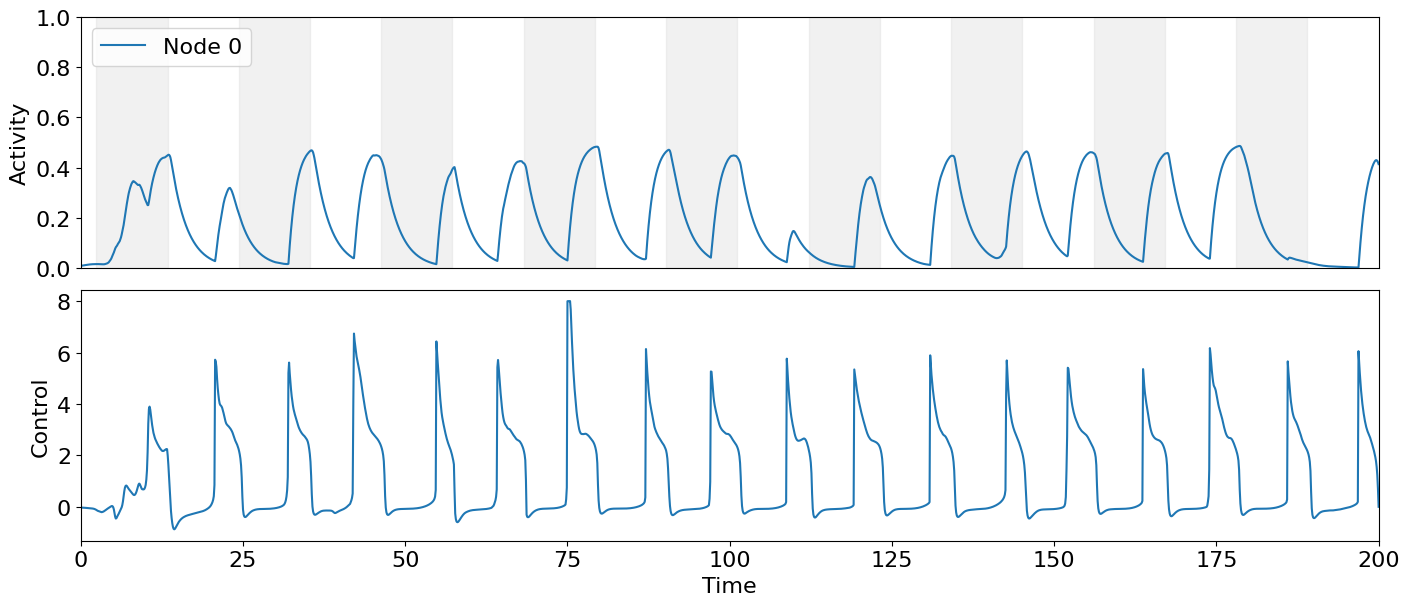

w2 =  0.0005
sigma =  0.0
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -0.0008090521125424465
Converged in iteration 2 with cost -0.0008090521125424465
Final cost : -0.0008090521125424465
Compute control for a deterministic system
Cost in iteration 0: -0.0008090521125424465
Converged in iteration 1 with cost -0.0008090521125424465
Final cost : -0.0008090521125424465
Compute control for a deterministic system
Cost in iteration 0: -0.0008090521125424465
Converged in iteration 1 with cost -0.0008090521125424465
Final cost : -0.0008090521125424465
MININD =  0


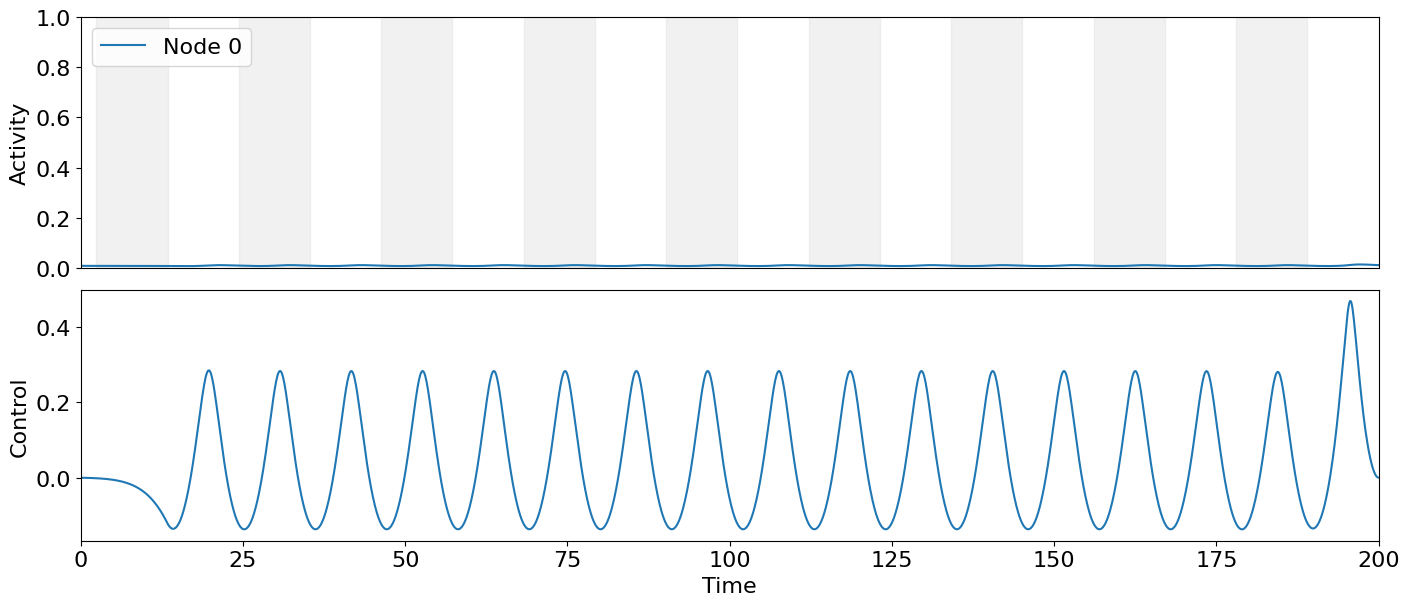

sigma =  0.1
Optimal control with target oscillation period
Compute control for a noisy system
Mean cost in iteration 0: -0.04352726573843747
Mean cost in iteration 5: -0.04289284083522613
Mean cost in iteration 10: -0.04158214706404183
Mean cost in iteration 15: -0.04354981245723083
Mean cost in iteration 20: -0.044337837084579425
Mean cost in iteration 25: -0.041315952927808756
Mean cost in iteration 30: -0.04348575797914046
Minimal cost found at iteration 6
Final cost validated with 100 noise realizations : -0.04283407657559179
Compute control for a noisy system
Mean cost in iteration 0: -0.04338646193922864
Mean cost in iteration 5: -0.043331502854104684
Mean cost in iteration 10: -0.04282444529120869
Mean cost in iteration 15: -0.04350963755751601
Mean cost in iteration 20: -0.043087320988949955
Mean cost in iteration 25: -0.04279354133285828
Mean cost in iteration 30: -0.043911781216368226
Minimal cost found at iteration 6
Final cost validated with 100 noise realizations : -0.043

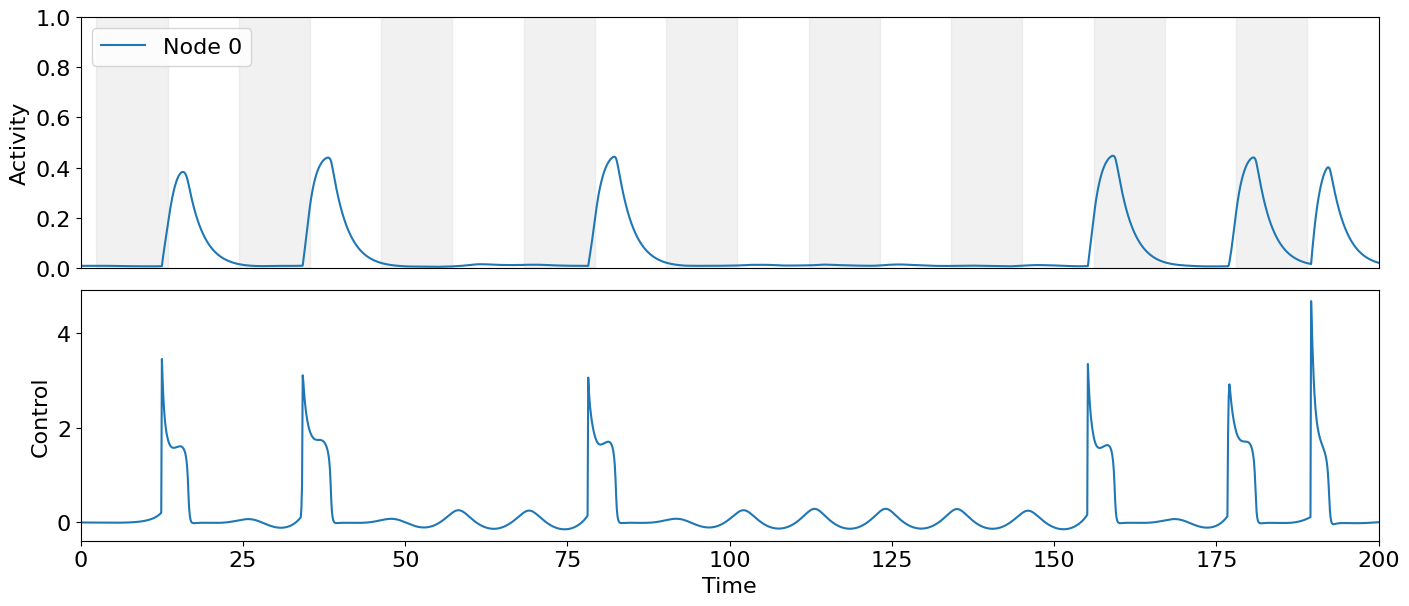

sigma =  0.2
Optimal control with target oscillation period
Compute control for a noisy system
Mean cost in iteration 0: -0.01777812951533591
Mean cost in iteration 5: -0.018280787190106774
Mean cost in iteration 10: -0.0173010674767951
Mean cost in iteration 15: -0.018719498374522713
Mean cost in iteration 20: -0.01575897743708713
Mean cost in iteration 25: -0.01705234276575126
Mean cost in iteration 30: -0.01685300844049554
Minimal cost found at iteration 29
Final cost validated with 100 noise realizations : -0.01726666103350354
Compute control for a noisy system
Mean cost in iteration 0: -0.019392836611982996
Mean cost in iteration 5: -0.01789230126651336
Mean cost in iteration 10: -0.01593108777126433
Mean cost in iteration 15: -0.018186340591288534
Mean cost in iteration 20: -0.01743131740713653
Mean cost in iteration 25: -0.016431327520352264
Mean cost in iteration 30: -0.015899840380919003
Minimal cost found at iteration 47
Final cost validated with 100 noise realizations : -0.0

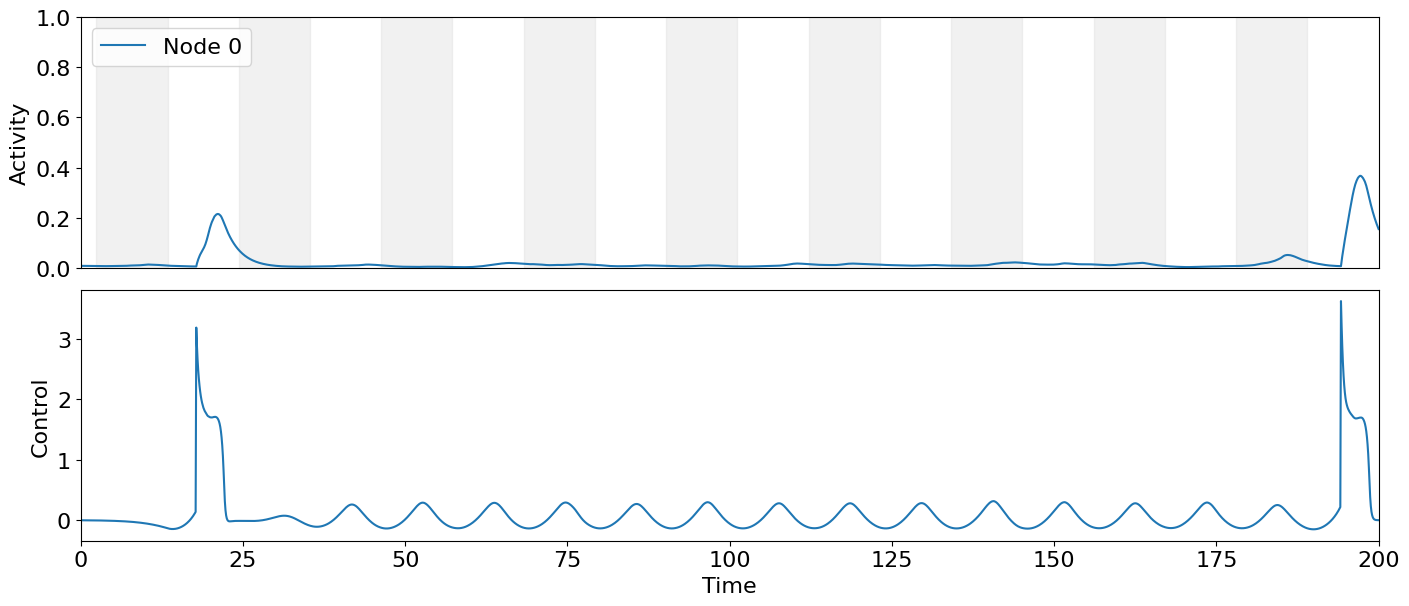

sigma =  0.3
Optimal control with target oscillation period
Compute control for a noisy system
Mean cost in iteration 0: -0.053428088380340355
Mean cost in iteration 5: -0.05095397367703987
Mean cost in iteration 10: -0.04761961203795399
Mean cost in iteration 15: -0.052714220028687774
Mean cost in iteration 20: -0.049165694862009564
Mean cost in iteration 25: -0.048729831653206886
Mean cost in iteration 30: -0.05280087774433627
Minimal cost found at iteration 19
Final cost validated with 100 noise realizations : -0.05482995112850654
Compute control for a noisy system
Mean cost in iteration 0: -0.05471034199170004
Mean cost in iteration 5: -0.05133503341993976
Mean cost in iteration 10: -0.05305757565549187
Mean cost in iteration 15: -0.049310927820596664
Mean cost in iteration 20: -0.054661155071270194
Mean cost in iteration 25: -0.05387455438907836
Mean cost in iteration 30: -0.054994262053027654
Minimal cost found at iteration 31
Final cost validated with 100 noise realizations : -0

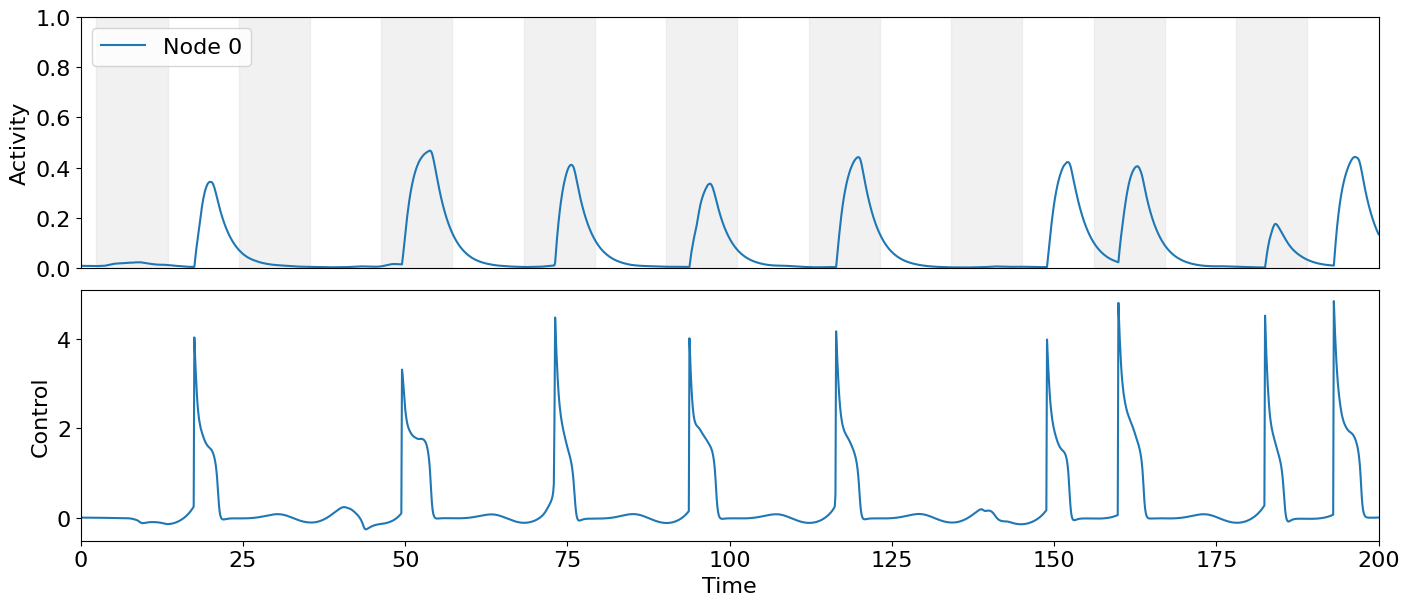

sigma =  0.4
Optimal control with target oscillation period
Compute control for a noisy system
Mean cost in iteration 0: -0.05120616285373277
Mean cost in iteration 5: -0.056456272951161325
Mean cost in iteration 10: -0.05145811896592001
Mean cost in iteration 15: -0.0470517132874612
Mean cost in iteration 20: -0.0477965922532209
Mean cost in iteration 25: -0.04744556363825169
Mean cost in iteration 30: -0.053281708919911776
Minimal cost found at iteration 5
Final cost validated with 100 noise realizations : -0.054726480460426524
Compute control for a noisy system
Mean cost in iteration 0: -0.05445670950792899
Mean cost in iteration 5: -0.04609319855224743
Mean cost in iteration 10: -0.044497336534874546
Mean cost in iteration 15: -0.05238312237711233
Mean cost in iteration 20: -0.04550671264732426
Mean cost in iteration 25: -0.05174049742147838
Mean cost in iteration 30: -0.04888505773078949
Minimal cost found at iteration 5
Final cost validated with 100 noise realizations : -0.052956

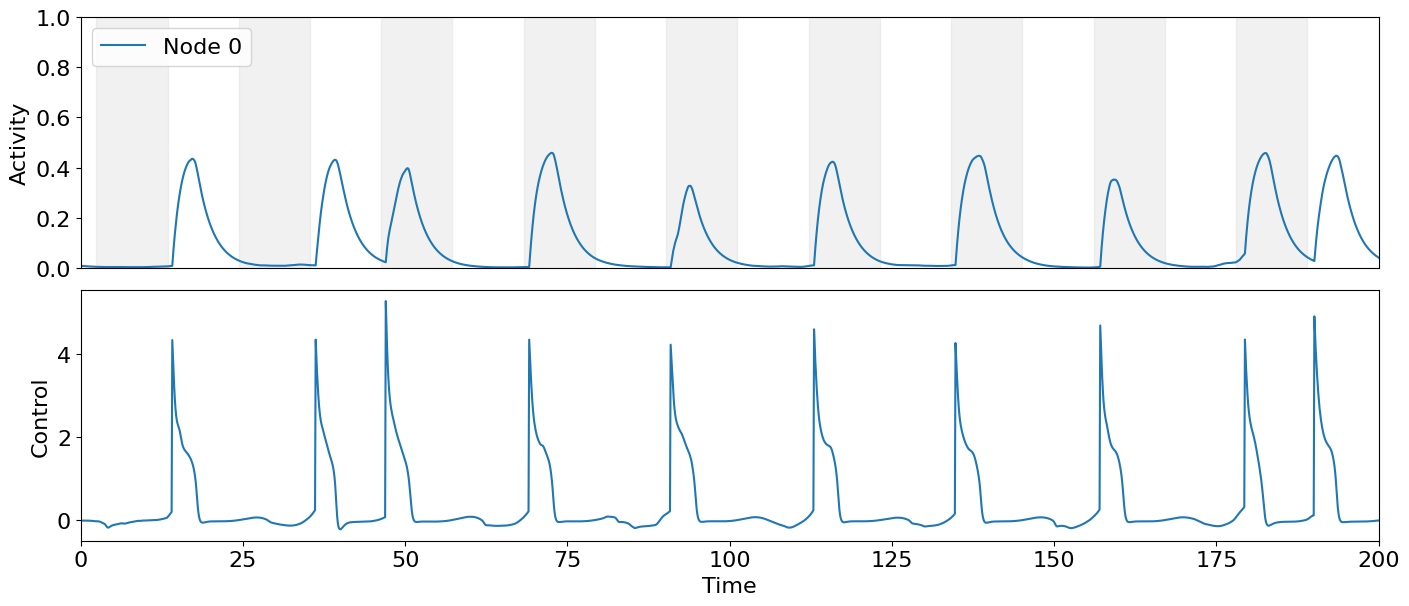

sigma =  0.5
Optimal control with target oscillation period
Compute control for a noisy system
Mean cost in iteration 0: -0.04536930141285176
Mean cost in iteration 5: -0.0390369085804629
Mean cost in iteration 10: -0.042468847773186394
Mean cost in iteration 15: -0.047002601637399236
Mean cost in iteration 20: -0.04244687812472292
Mean cost in iteration 25: -0.04723695541922401
Mean cost in iteration 30: -0.040010635023042564
Minimal cost found at iteration 24
Final cost validated with 100 noise realizations : -0.044951455536697056
Compute control for a noisy system
Mean cost in iteration 0: -0.049722682121065745
Mean cost in iteration 5: -0.04012498023110069
Mean cost in iteration 10: -0.03953626420774273
Mean cost in iteration 15: -0.042242959429220864
Mean cost in iteration 20: -0.03846464400945972
Mean cost in iteration 25: -0.04844367781640804
Mean cost in iteration 30: -0.042609199573782355
Minimal cost found at iteration 24
Final cost validated with 100 noise realizations : -0.

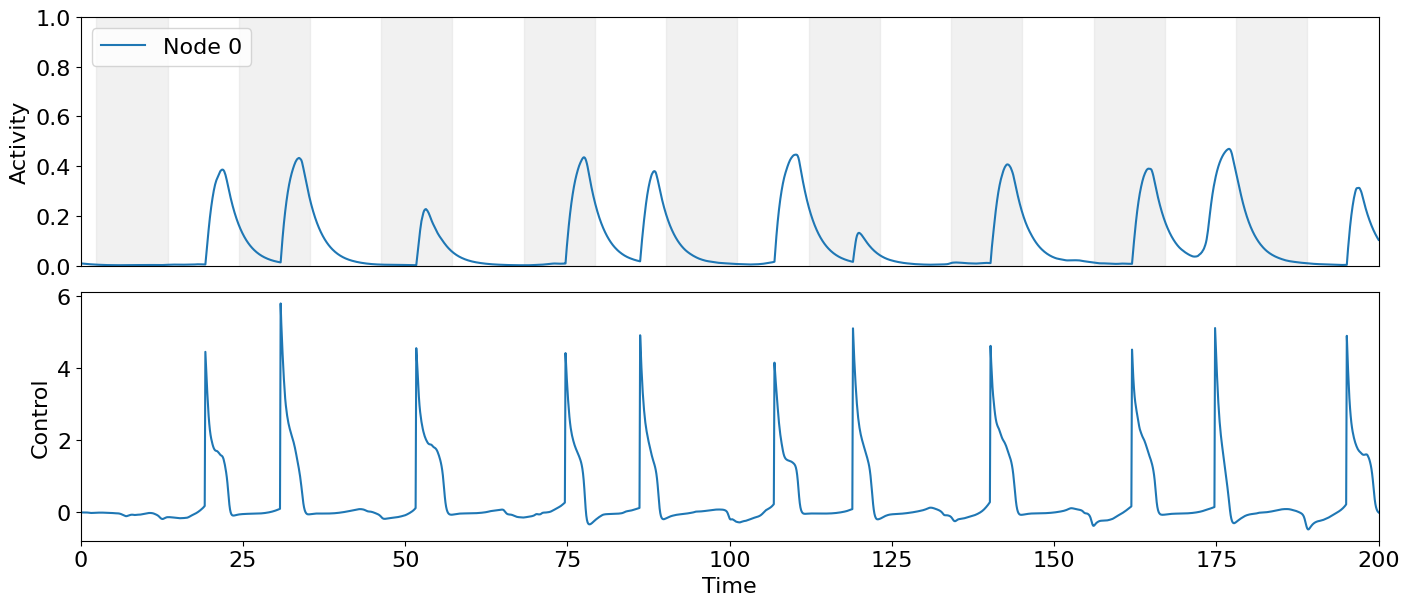

w2 =  0.001
sigma =  0.0
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -0.00036523694534214876
Converged in iteration 2 with cost -0.00036523694534214876
Final cost : -0.00036523694534214876
Compute control for a deterministic system
Cost in iteration 0: -0.00036523694534214876
Converged in iteration 1 with cost -0.00036523694534214876
Final cost : -0.00036523694534214876
Compute control for a deterministic system
Cost in iteration 0: -0.00036523694534214876
Converged in iteration 1 with cost -0.00036523694534214876
Final cost : -0.00036523694534214876
MININD =  0


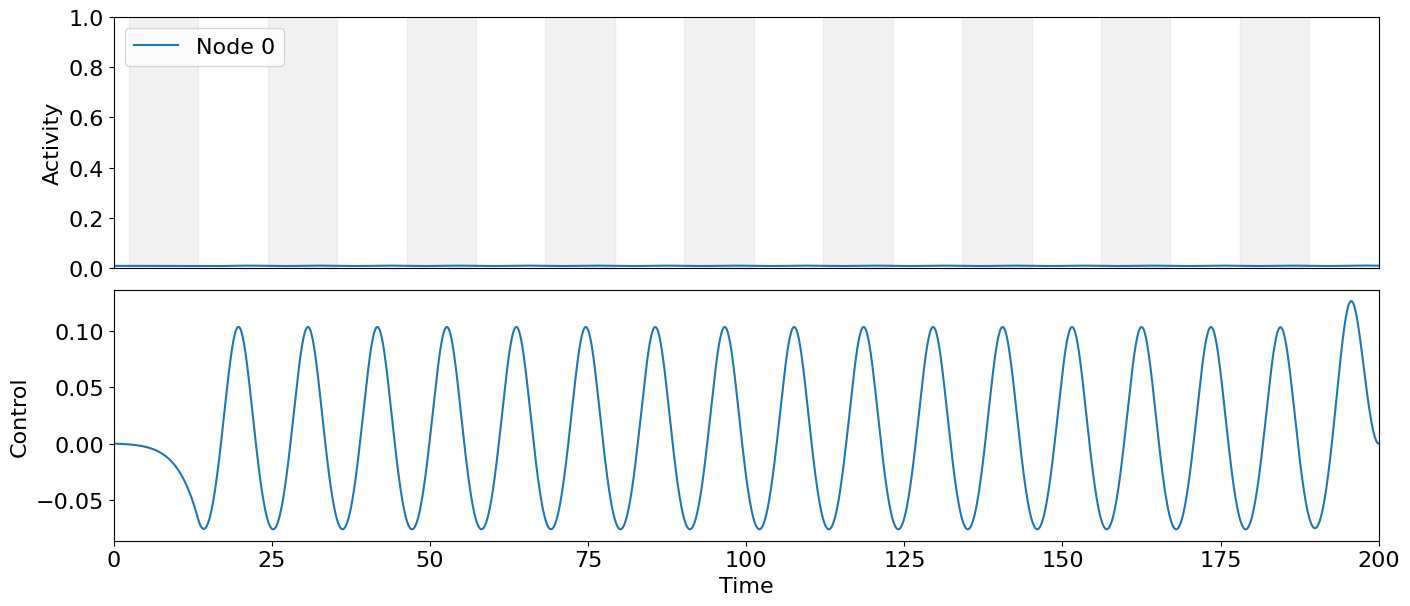

sigma =  0.1
Optimal control with target oscillation period
Compute control for a noisy system
Mean cost in iteration 0: -0.00045096025271531474
Mean cost in iteration 5: -0.00020864175096122788
Mean cost in iteration 10: -0.0003208717292010126
Mean cost in iteration 15: -0.0003843668542829404
Mean cost in iteration 20: -0.0003980844194124174
Mean cost in iteration 25: -0.00042422948377238417
Mean cost in iteration 30: -0.00039114182098370757
Minimal cost found at iteration 14
Final cost validated with 100 noise realizations : -0.00041177046350585153
Compute control for a noisy system
Mean cost in iteration 0: -0.00037987879727764196
Mean cost in iteration 5: -0.0004305486986933187
Mean cost in iteration 10: -0.0004523077790918379
Mean cost in iteration 15: -0.0004268576333139527
Mean cost in iteration 20: -0.00042747284296331485
Mean cost in iteration 25: -0.0004862109231730718
Mean cost in iteration 30: -0.00041283987795374505
Minimal cost found at iteration 59
Final cost validated w

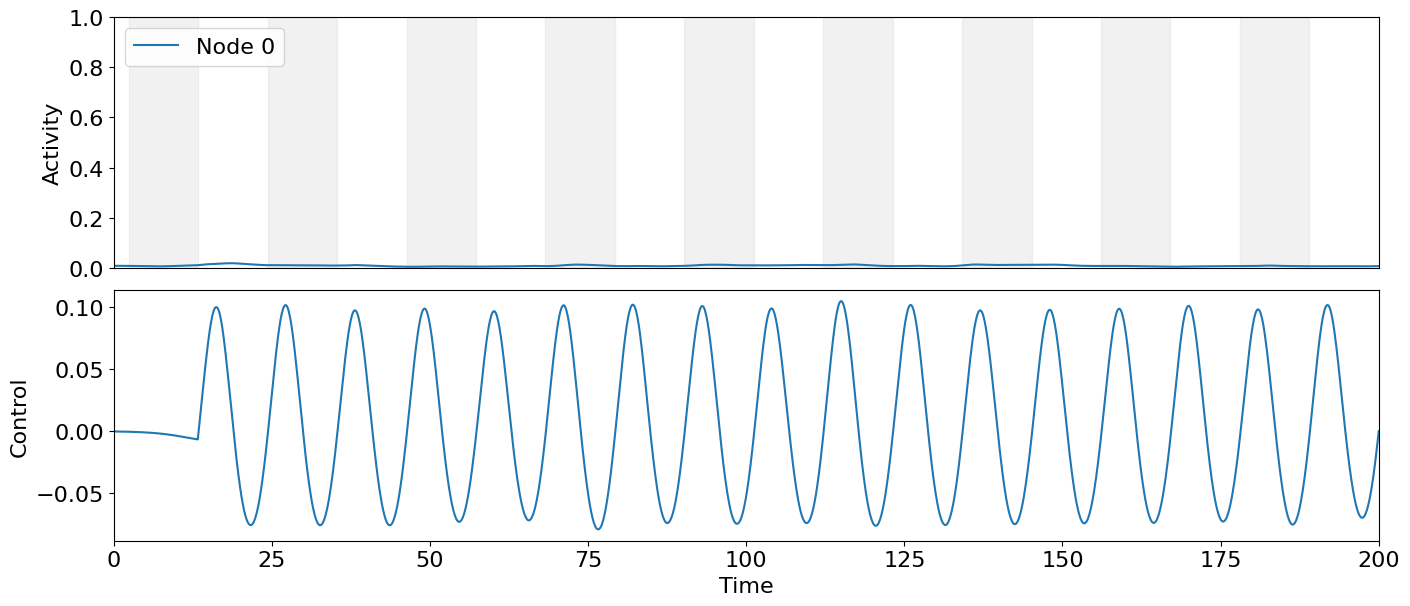

sigma =  0.2
Optimal control with target oscillation period
Compute control for a noisy system
Mean cost in iteration 0: -0.0034896708555738594
Mean cost in iteration 5: -0.002806735793893009
Mean cost in iteration 10: -0.005521499771508384
Mean cost in iteration 15: -0.004945706813084404
Mean cost in iteration 20: -0.006392836147660894
Mean cost in iteration 25: -0.00532441189307827
Mean cost in iteration 30: -0.0030368088499425046
Minimal cost found at iteration 20
Final cost validated with 100 noise realizations : -0.004250431149285007
Compute control for a noisy system
Mean cost in iteration 0: -0.003660495313887677
Mean cost in iteration 5: -0.004284888796845315
Mean cost in iteration 10: -0.006611049979740563
Mean cost in iteration 15: -0.0038073106680254405
Mean cost in iteration 20: -0.0036368253626433977
Mean cost in iteration 25: -0.004868867436744542
Mean cost in iteration 30: -0.004420859841458998
Minimal cost found at iteration 40
Final cost validated with 100 noise realiz

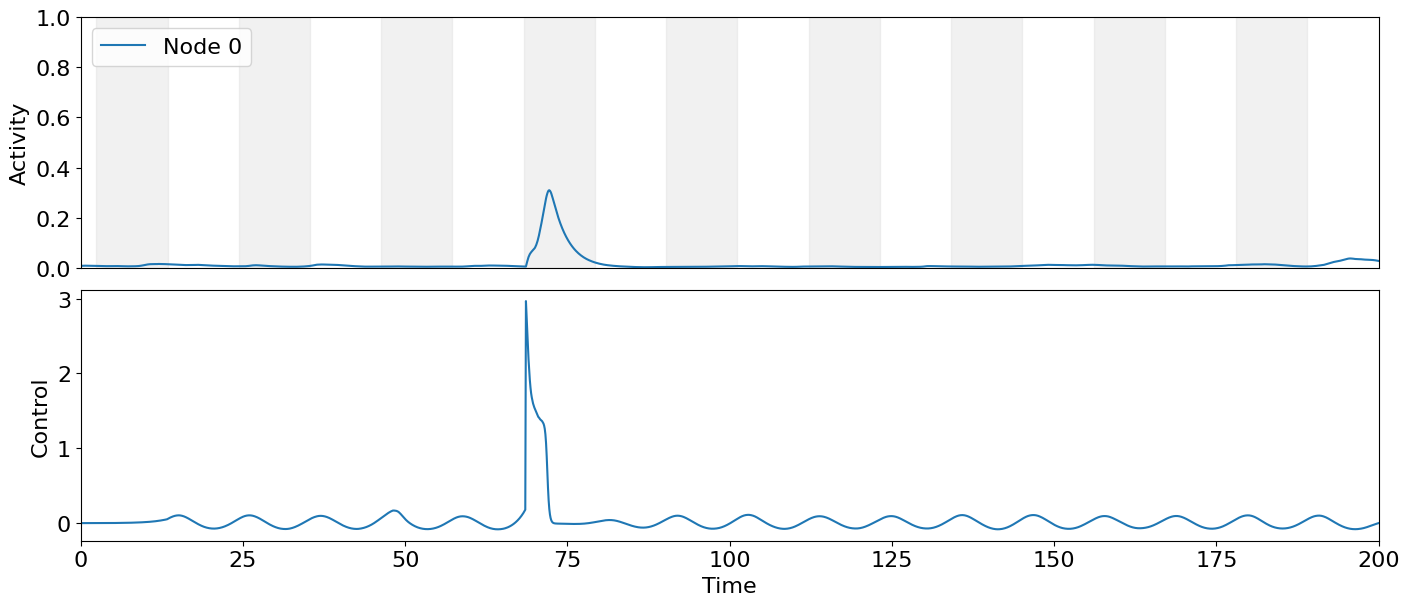

sigma =  0.3
Optimal control with target oscillation period
Compute control for a noisy system
Mean cost in iteration 0: -0.008773221203320783
Mean cost in iteration 5: -0.008377408189863938
Mean cost in iteration 10: -0.0078040913288828255
Mean cost in iteration 15: -0.00756033709726536
Mean cost in iteration 20: -0.009858365735747714
Mean cost in iteration 25: -0.00407766760438598
Mean cost in iteration 30: -0.010155745616295961
Minimal cost found at iteration 14
Final cost validated with 100 noise realizations : -0.010429390113451266
Compute control for a noisy system
Mean cost in iteration 0: -0.008074040859965123
Mean cost in iteration 5: -0.011427166608411848
Mean cost in iteration 10: -0.008978692542202339
Mean cost in iteration 15: -0.007418228306234445
Mean cost in iteration 20: -0.006017086197481839
Mean cost in iteration 25: -0.006449011976738086
Mean cost in iteration 30: -0.006135687608978096
Minimal cost found at iteration 33
Final cost validated with 100 noise realizatio

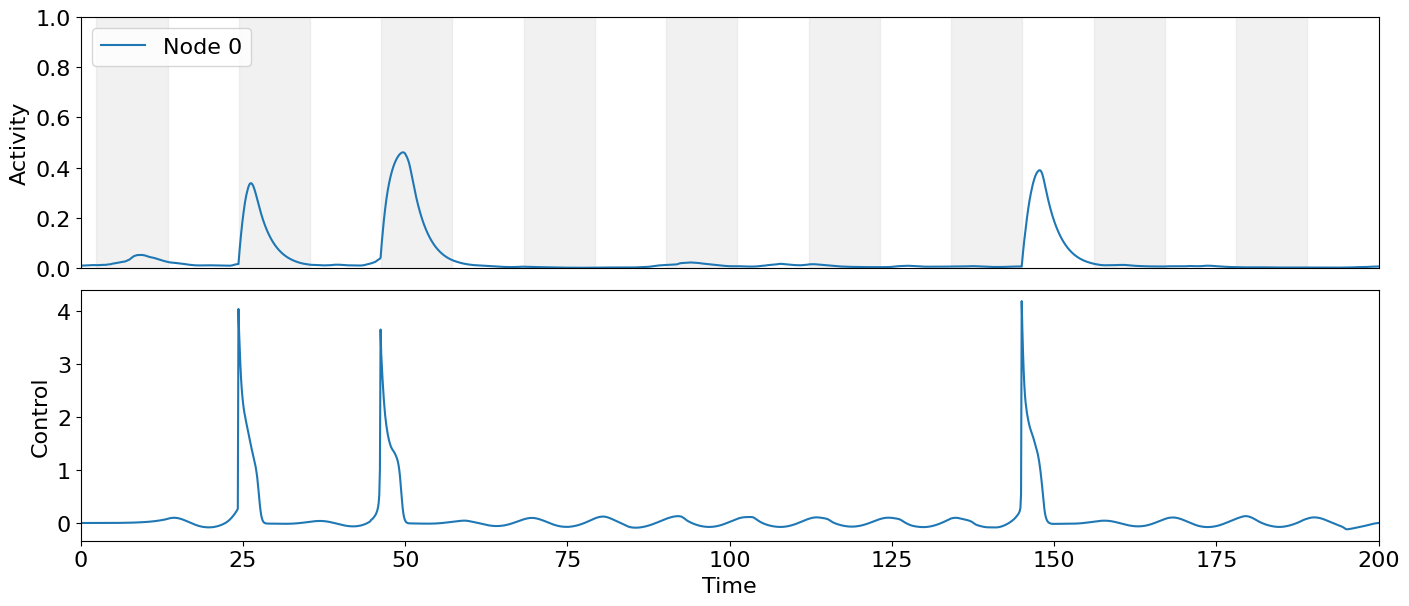

sigma =  0.4
Optimal control with target oscillation period
Compute control for a noisy system
Mean cost in iteration 0: -0.008366280446544755
Mean cost in iteration 5: -0.0068226612449006786
Mean cost in iteration 10: -0.010023322802171046
Mean cost in iteration 15: -0.014560864371142979
Mean cost in iteration 20: -0.011385737302637861
Mean cost in iteration 25: -0.014968168868384446
Mean cost in iteration 30: -0.013419036278147296
Minimal cost found at iteration 18
Final cost validated with 100 noise realizations : -0.010606274742899728
Compute control for a noisy system
Mean cost in iteration 0: -0.008254045371586902
Mean cost in iteration 5: -0.01022010128556372
Mean cost in iteration 10: -0.0006391615607748702
Mean cost in iteration 15: -0.011490180840232577
Mean cost in iteration 20: -0.008795407503736575
Mean cost in iteration 25: -0.011569539712644992
Mean cost in iteration 30: -0.0071815105277119986
Minimal cost found at iteration 18
Final cost validated with 100 noise realiza

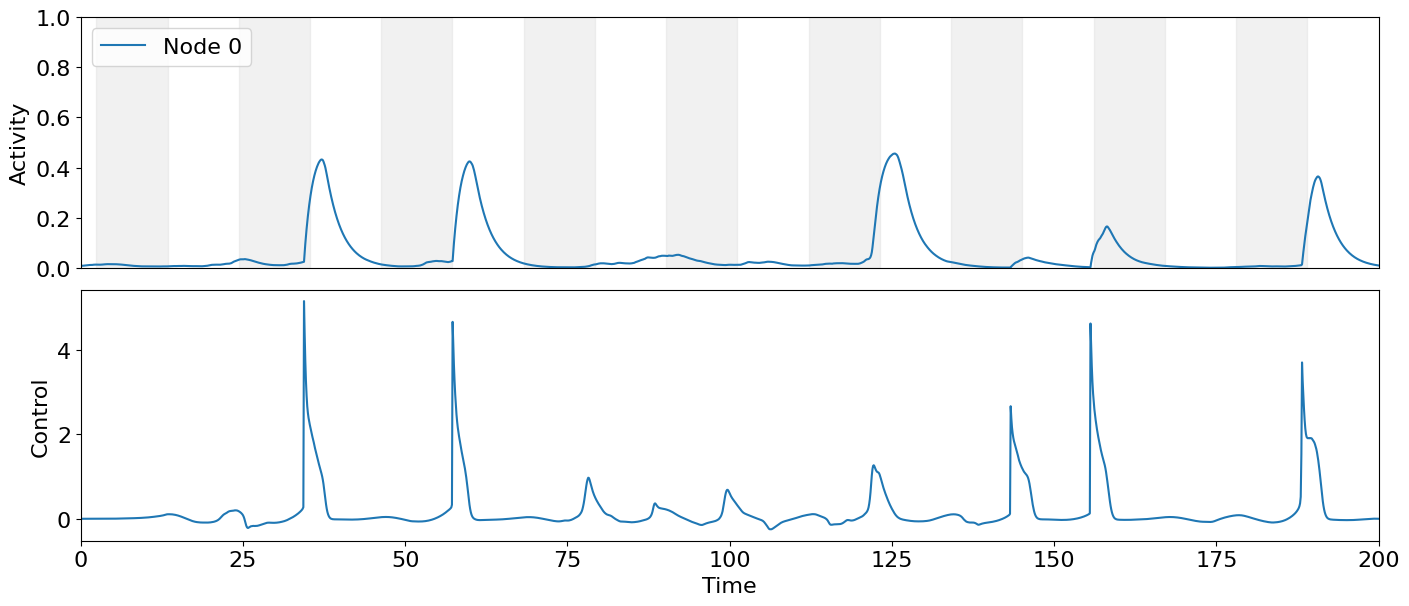

sigma =  0.5
Optimal control with target oscillation period
Compute control for a noisy system
Mean cost in iteration 0: -0.00765089540494691
Mean cost in iteration 5: -0.016185105786446517
Mean cost in iteration 10: -0.008700710530511305
Mean cost in iteration 15: -0.002762183451374429
Mean cost in iteration 20: -0.008811708258881026
Mean cost in iteration 25: -0.010580829099899946
Mean cost in iteration 30: -0.009780590162312258
Minimal cost found at iteration 18
Final cost validated with 100 noise realizations : -0.007801791839593566
Compute control for a noisy system
Mean cost in iteration 0: -0.0022634429748309157
Mean cost in iteration 5: -0.006213228287679697
Mean cost in iteration 10: -0.0045175971247475005
Mean cost in iteration 15: -0.011300687041538455
Mean cost in iteration 20: -0.011790126795405777
Mean cost in iteration 25: -0.015091135903559798
Mean cost in iteration 30: -0.00810502515723479
Minimal cost found at iteration 18
Final cost validated with 100 noise realizati

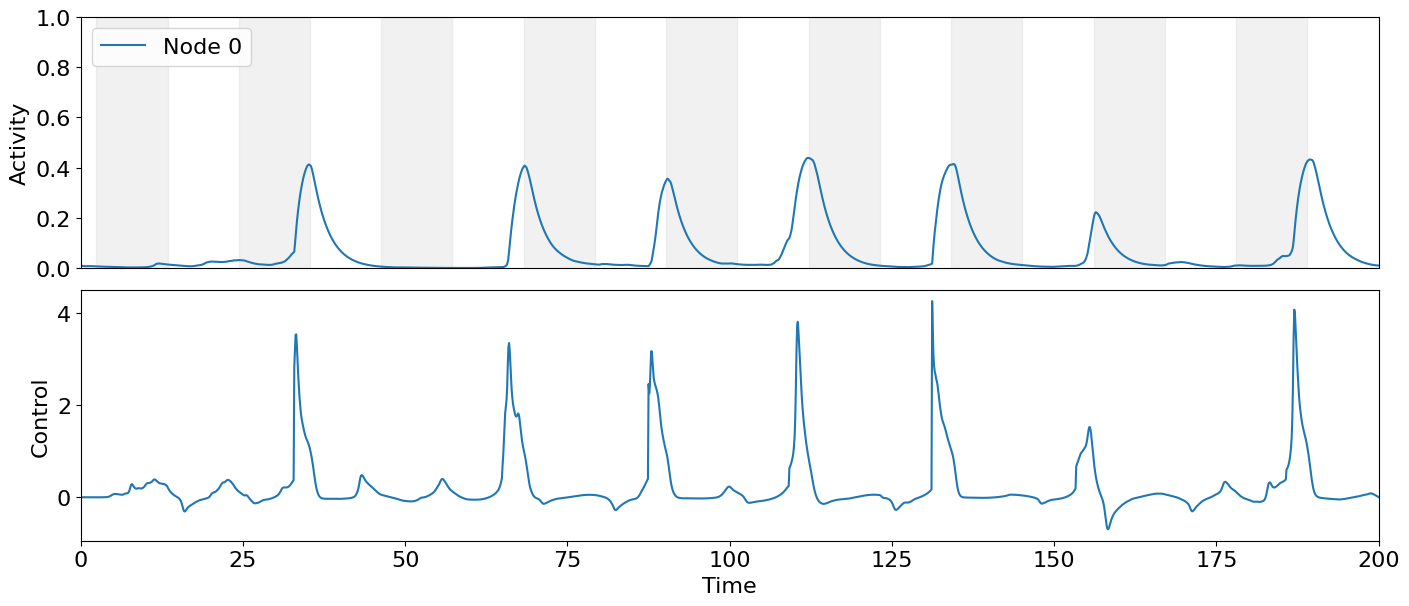

itar =  1
itar =  2


In [155]:
it = 30
### different w2 for different points: down state 2. * 1e-4 // up state 2. * 1e-5 // osc state
#results["conv"] = np.zeros((len(comp_points), len(target_array), len(w2_array), len(sigma_array)))


pr = np.arange(0,101,5)
maxstr = 10.
nmaxdel = model.getMaxDelay()
init_control = zero_control.copy()

for pind in range(len(comp_points)):

    if pind not in [0]:
        continue

    print("pind = ", pind)
    p = comp_points[pind]
    
    testd = 1000.
    model.params.duration = testd
    test_input = ZeroInput().generate_input(duration=testd+model.params.dt, dt=model.params.dt)
    model.params["exc_ext"] = test_input + p[0]
    model.params["inh_ext"] = test_input + p[1]
    model.params.sigma_ou = 0.
    model.run()

    einit = np.zeros((N, nmaxdel+1))
    iinit = np.zeros((N, nmaxdel+1))


    for n in range(N):
        einit[n,:] = model.exc[n,-1]
        iinit[n,:] = model.inh[n,-1]

    model.params.duration = duration

    model.params["exc_ext"] = zero_control[:,0,:] + p[0]
    model.params["inh_ext"] = zero_control[:,0,:] + p[1]

    model.params["exc_init"] = einit
    model.params["inh_init"] = iinit

    model.run()

    for itar in range(len(target_array)):

        print("itar = ", itar)

        if itar not in [0]:
            continue

        target_period = target_array[itar]
        i00 = 0
        int0 = np.around( (duration - i00 * target_period) / model.params.dt, 0).astype(int)     
        while int0 > 220:
            i00 += 1
            int0 = np.around( (duration - i00 * target_period) / model.params.dt, 0).astype(int)

        for iw in range(len(w2_array)):

            if iw not in [0,1,2]:
                continue

            print("w2 = ", w2_array[iw])

            for isi in range(len(sigma_array)):
            
                print("sigma = ", sigma_array[isi])

                if results["costs"][pind][itar][iw][isi] < -0.5: continue

                if results["conv"][pind][itar][iw][isi] == 1: continue

                model.params.sigma_ou = sigma_array[isi]

                if isi == 0: model_controlled = oc_wc.OcWc(model, target_period, print_array=pr, cost_interval=(int0,None), cost_matrix=costmat, control_matrix = controlmat)
                else: model_controlled = oc_wc.OcWc(model, target_period, print_array=pr, cost_interval=(int0,None), cost_matrix=costmat, control_matrix = controlmat, M=M, M_validation=100)
                model_controlled.maximum_control_strength = maxstr
                model_controlled.weights["w_p"] = 0.
                model_controlled.weights["w_2"] = w2_array[iw]
                model_controlled.weights["w_f"] = 1.

                #model_controlled.control = results["controls"][pind][itar][iw][0].copy()
                #model_controlled.update_input()

                if type(results["controls"][pind][itar][iw][isi]) != type(None):
                    model_controlled.control = results["controls"][pind][itar][iw][isi].copy()
                    model_controlled.update_input()

                model_controlled.step = 1e5
                model_controlled.optimize(it)

                model_controlled.step = 1e3
                model_controlled.optimize(it)

                model_controlled.step = 1e1
                model_controlled.optimize(it)

                minind = np.argmin(model_controlled.cost_history)
                print("MININD = ", minind)
                if minind < 10 and minind <= 0.2*it:
                    results["conv"][pind][itar][iw][isi] = 1

            
                results["costs"][pind][itar][iw][isi] = np.amin(model_controlled.cost_history)
                results["controls"][pind][itar][iw][isi] = model_controlled.control.copy()

                timings, periods = getperiods(model_controlled.get_xs(), target_period, duration)
                results["timings"][pind][itar][iw][isi] = timings
                results["periods"][pind][itar][iw][isi] = periods

                fname = str(pind) + "_" + str(itar) + "_"  + str(iw) + "_" + str(isi) + ".png"
                plot_oc_nw(N, duration, dt, model_controlled.get_xs(), target_period,  model_controlled.control, filename= os.path.join(dir, fname))

In [157]:
print(np.round(results["costs"][0][0],4))

[[-0.1819 -0.1817 -0.1792 -0.1654 -0.1634 -0.154 ]
 [-0.0008 -0.0446 -0.0193 -0.0604 -0.0575 -0.0559]
 [-0.0004 -0.0005 -0.0066 -0.0146 -0.0156 -0.0182]
 [ 0.      0.      0.      0.      0.      0.    ]]


In [156]:
with open('osc_1n.pickle', 'wb') as f:
    pickle.dump(results, f)

In [6]:
with open('osc_1n.pickle', 'rb') as f:
    res_read = pickle.load(f)
    print(res_read.keys() )

results = res_read.copy()

dict_keys(['controls', 'periods', 'timings', 'costs', 'conv', 'Fcost'])


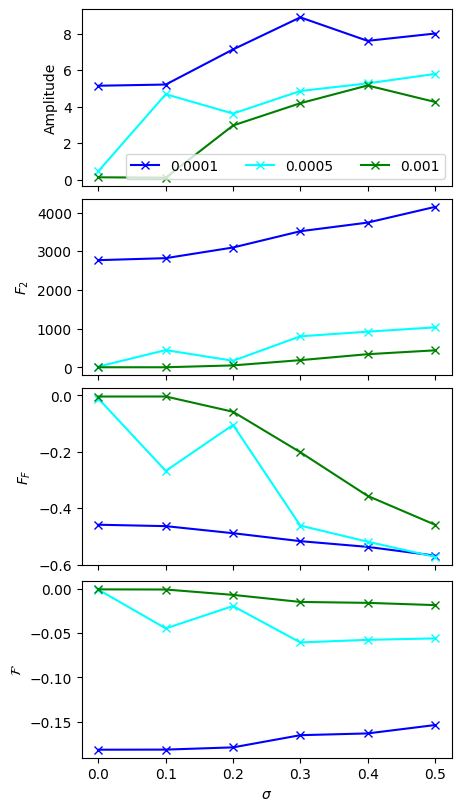

In [10]:
pind, itar = 0,0
ylabel = w2_array[:3]

c = ["blue", "cyan", "green", "red", "pink"]

fig, ax = plt.subplots(4,1, sharex=True, sharey=False, figsize=(4.5,8), constrained_layout=True)


for iw in range(len(ylabel)):
    L2cost = []
    fcost = []
    ctot = []
    amp = []
    for isi in range(len(sigma_array)):
        L2cost.append(np.sum(cost_functions.L2_cost(results["controls"][pind][itar][iw][isi])))
        ctot.append(results["costs"][pind][itar][iw][isi])
        fcost.append(ctot[-1] - w2_array[iw] * L2cost[-1])
        amp.append(np.amax(np.abs(results["controls"][pind][itar][iw][isi])))

    ax[0].plot(sigma_array, amp, marker="x", color=c[iw], label=str(w2_array[iw]))
    ax[1].plot(sigma_array, L2cost, marker="x", color=c[iw])
    ax[2].plot(sigma_array, fcost, marker="x", color=c[iw])
    ax[3].plot(sigma_array, ctot, marker="x", color=c[iw])


ax[3].set_xlabel(r"$\sigma$")
ax[0].set_ylabel(r"Amplitude")
ax[0].legend(loc="lower right", ncol=3)

ax[2].set_ylabel(r"$F_F$")
ax[1].set_ylabel(r"$F_2$")
ax[3].set_ylabel(r"$\mathcal{F}$")

plt.savefig(os.path.join(dir, "noisy_success.png"))
plt.show()

In [ ]:
xl = ["Down F", "Up F", "Osc F"]

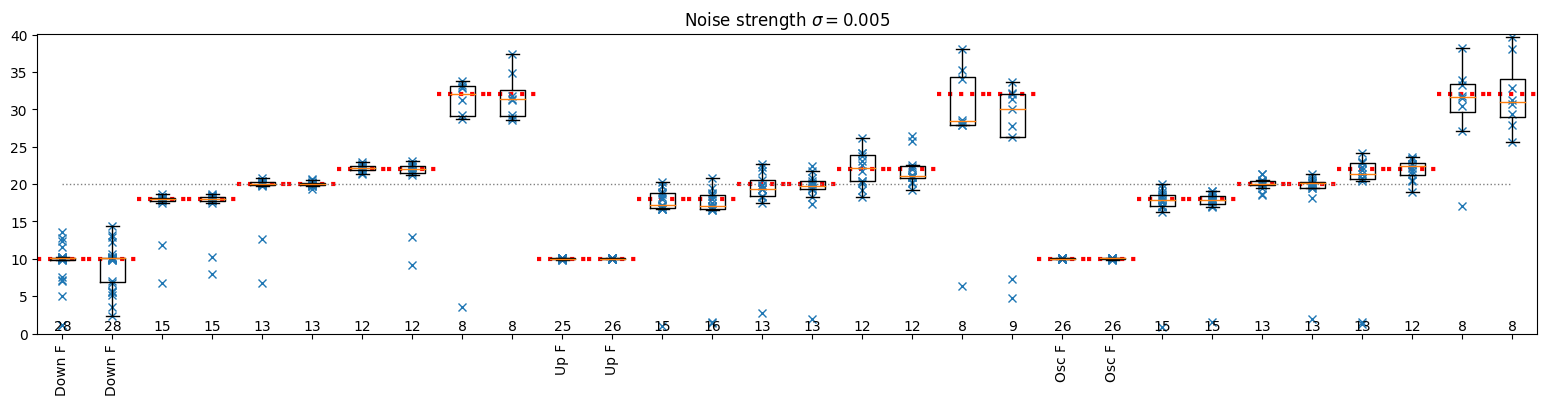

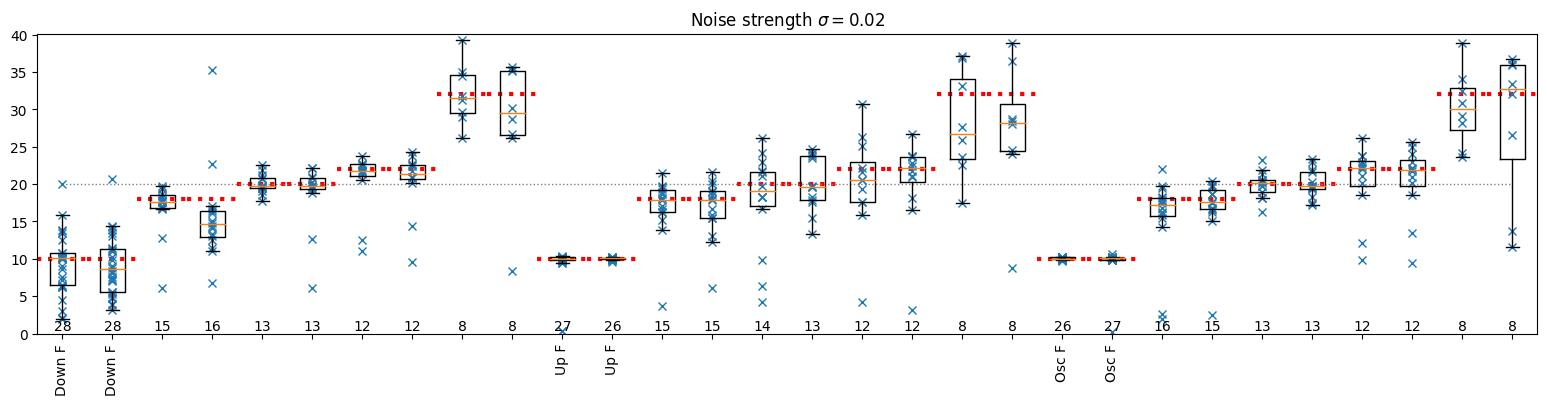

In [ ]:
for isi in range(len(sigma_array)):
    ydata = []
    xlabels = []
    fig = plt.figure(figsize =(15, 3))
    ax = fig.add_axes([0, 0, 1, 1])

    xpos = 0

    for pind in range(len(comp_points)):
        for itar in range(len(target_array)):

            target_period = target_array[itar]
            #xpos = 15*imet + 5*pind + itar

            for im in range(len(M_array)):

                if itar != 0:
                    xlabels.append("")
                else:
                    xlabels.append(xl[pind])

                data = results["periods"][pind][itar][im][isi]
                ydata_ = []
                
                if data is None:
                    ydata.append(ydata_)
                    xpos += 1
                    continue

                n_datapoints = 0

                for n in range(N):
                    n_datapoints += len(data[n])
                    
                    if len(data[n]) != 0:
                        for dpoint in data[n]:
                            ax.plot(xpos+1, dpoint, marker="x", color=colors[n])
                            ydata_.append(dpoint)

                ydata.append(ydata_)

                ax.text(xpos+1, 1, str(n_datapoints), horizontalalignment='center', verticalalignment='center')
                ax.hlines(target_period, xpos+0.5, xpos+1.5, linestyle=":", color="red", linewidth =3)

                xpos += 1


    ax.boxplot(ydata, showfliers=False)
    ax.plot()
    ax.hlines(period, 1., len(xlabels), linestyle=":", color="grey",linewidth = 1)
    ax.set_xticklabels(xlabels, rotation=90)
    ax.set_ylim(0., 2.*period)
    ax.set_title(r"Noise strength $\sigma = $" + "{}".format(sigma_array[isi]))
    plt.show()
    fig.savefig(os.path.join(dir, "periods_" + str(isi) + ".png"), bbox_inches='tight')